# Week 5

## Q1 - numeric check of the by-hand normalization

In [1]:
import numpy as np

A = np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float)
A_tilde = A + np.eye(3)
D_tilde = np.diag(A_tilde.sum(axis=1))
D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D_tilde)))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
print(A_hat)

[[0.5        0.40824829 0.        ]
 [0.40824829 0.33333333 0.40824829]
 [0.         0.40824829 0.5       ]]


## Q2.1 - NumPy-only GCN layer
$H = \text{ReLU}(\hat{A}XW)$, tested on the Q1 graph with random $X$, $W$.

In [2]:
def relu(x):
    return np.maximum(0, x)

def gcn_layer(A_hat, X, W):
    return relu(A_hat @ X @ W)

np.random.seed(0)
X = np.random.randn(3, 4)   # 3 nodes, 4 input features
W = np.random.randn(4, 2)   # project to 2 output features

H = gcn_layer(A_hat, X, W)
print(H)

[[2.80530784 0.        ]
 [2.60658792 0.        ]
 [1.35041084 0.        ]]


## Q3.2 - eigenvalue check: unnormalized vs. renormalized, on the karate club graph

In [3]:
import networkx as nx

G = nx.karate_club_graph()
A_kc = nx.to_numpy_array(G)

D_kc = np.diag(A_kc.sum(axis=1))
D_kc_inv_sqrt = np.diag(1/np.sqrt(np.diag(D_kc)))
norm_no_selfloop = D_kc_inv_sqrt @ A_kc @ D_kc_inv_sqrt

A_kc_tilde = A_kc + np.eye(A_kc.shape[0])
D_kc_tilde = np.diag(A_kc_tilde.sum(axis=1))
D_kc_tilde_inv_sqrt = np.diag(1/np.sqrt(np.diag(D_kc_tilde)))
renormalized = D_kc_tilde_inv_sqrt @ A_kc_tilde @ D_kc_tilde_inv_sqrt

eig_unnorm = np.linalg.eigvalsh(np.eye(A_kc.shape[0]) + norm_no_selfloop)
eig_renorm = np.linalg.eigvalsh(renormalized)

print("I_N + D^-1/2 A D^-1/2 range:", eig_unnorm.min(), "to", eig_unnorm.max())
print("Renormalized D~^-1/2 A~ D~^-1/2 range:", eig_renorm.min(), "to", eig_renorm.max())

I_N + D^-1/2 A D^-1/2 range: 0.3077608136332544 to 1.9999999999999998
Renormalized D~^-1/2 A~ D~^-1/2 range: -0.5818560187660472 to 1.0000000000000002


## Q4 - over-smoothing: GCN depth vs. test accuracy on Cora

In [4]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0]
print(data)

/opt/anaconda3/envs/nn/lib/python3.10/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        if num_layers == 1:
            self.convs.append(GCNConv(in_channels, out_channels))
        else:
            self.convs.append(GCNConv(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = F.relu(conv(x, edge_index))
        x = self.convs[-1](x, edge_index)
        return x

def train_and_eval(num_layers, epochs=200, lr=0.01, hidden=16):
    model = GCN(dataset.num_features, hidden, dataset.num_classes, num_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    return acc

[(2, 0.805), (4, 0.766), (8, 0.686), (16, 0.202)]


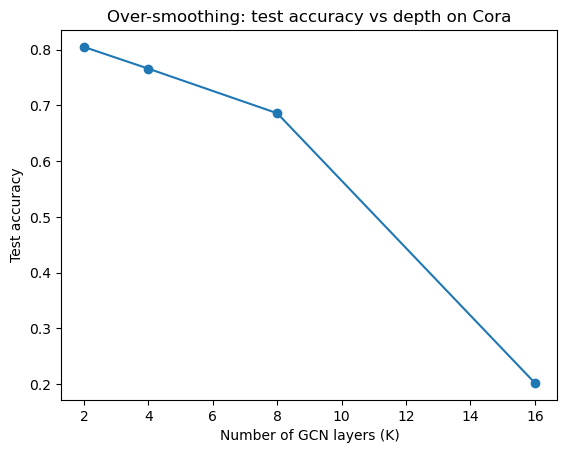

In [6]:
import matplotlib.pyplot as plt

Ks = [2, 4, 8, 16]
accs = [train_and_eval(k) for k in Ks]
print(list(zip(Ks, accs)))

plt.plot(Ks, accs, marker='o')
plt.xlabel('Number of GCN layers (K)')
plt.ylabel('Test accuracy')
plt.title('Over-smoothing: test accuracy vs depth on Cora')
plt.savefig('oversmoothing_plot.png')
plt.show()